# 03 — Estudo de caso: PASA

**Objetivo deste notebook:** aplicar as métricas construídas em
`02_data_quality.ipynb` a uma operadora específica — a PASA (Plano de
Assistência à Saúde do Aposentado da Vale, REG_ANS 331988) — seguindo um
processo investigativo: observação → hipótese → investigação → resultado →
revisão da interpretação quando necessário.

**Estrutura deste notebook:**
1. Evolução da sinistralidade da PASA
2. Hipótese do perfil etário da carteira e construção de um peer group
3. Composição do sinistro e limites de granularidade do dado público
4. Sinistralidade vs. resultado operacional completo
5. Taxa de glosa
6. Síntese e perguntas em aberto


In [1]:
import pandas as pd

pd.set_option('display.max_columns', 50)
PROCESSED = '../data/processed'
PASA = 331988

fato = pd.read_csv(f'{PROCESSED}/fato_financeiro.csv')
dim_operadora = pd.read_csv(f'{PROCESSED}/dim_operadora.csv')

ORDEM_TRIMESTRES = ['1T2025', '2T2025', '3T2025', '4T2025', '1T2026']


## 1. Evolução da sinistralidade da PASA

**Definição:** sinistralidade = despesa assistencial (conta 41) ÷ receita
assistencial (conta 31). É a métrica tradicional do setor para acompanhar a
relação entre o que é arrecadado e o que é gasto com eventos de saúde.


In [2]:
pasa = fato[fato['REG_ANS'] == PASA].copy()
pasa['sinistralidade'] = pasa['sinistro_liquido'] / pasa['receita_assistencial']
pasa = pasa.set_index('trimestre').reindex(ORDEM_TRIMESTRES)

pasa[['receita_assistencial', 'sinistro_liquido', 'sinistralidade']]


,receita_assistencial,sinistro_liquido,sinistralidade
trimestre,,,
1T2025,1.032425e+08,1.052215e+08,1.019169
2T2025,1.209190e+08,1.202225e+08,0.994240
3T2025,1.399568e+08,1.291123e+08,0.922515
4T2025,1.296747e+08,1.392516e+08,1.073853
1T2026,1.282669e+08,1.239007e+08,0.965960


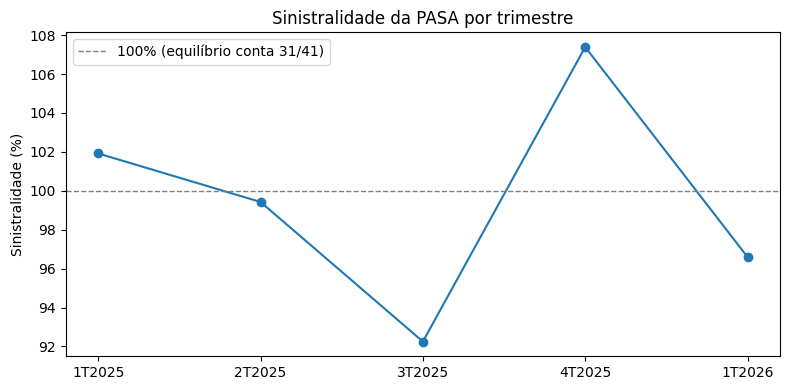

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pasa.index, pasa['sinistralidade'] * 100, marker='o')
ax.axhline(100, color='gray', linestyle='--', linewidth=1, label='100% (equilíbrio conta 31/41)')
ax.set_ylabel('Sinistralidade (%)')
ax.set_title('Sinistralidade da PASA por trimestre')
ax.legend()
plt.tight_layout()
plt.show()


**Observação:** a sinistralidade da PASA oscilou entre 92,3% e 107,4% nos
cinco trimestres analisados, com três dos cinco períodos acima de 100%. O
período coberto é curto (cinco trimestres), o que limita a distinção entre um
padrão persistente e uma fase específica de um ciclo mais longo não observável
com os dados disponíveis.

## 2. Hipótese do perfil etário da carteira

**Hipótese investigada:** por se tratar de um plano voltado especificamente a
aposentados, a carteira da PASA tenderia a ter idade média mais alta que a de
uma autogestão típica — e isso, isoladamente, poderia explicar uma
sinistralidade mais elevada, já que a utilização de serviços de saúde tende a
aumentar com a idade.

**Risco metodológico identificado:** comparar a PASA contra a mediana de
*todas* as autogestões (que inclui operadoras de empresas com força de
trabalho majoritariamente ativa) tenderia a favorecer a hipótese de forma
enviesada, pois a diferença de composição etária por si só já produziria uma
diferença de sinistralidade, independentemente de qualquer outro fator.

**Tratamento:** foi construído um grupo de comparação mais específico —
fundações de previdência e seguridade social vinculadas a empresas ou
categorias profissionais, que também tendem a ter carteira concentrada em
aposentados e pensionistas. A identificação foi feita por busca textual na
razão social do cadastro de operadoras (termos como "Fundação de Previdência",
"Seguridade Social"), não por um campo estruturado da ANS — portanto, é uma
aproximação, não uma classificação oficial.


In [4]:
# Peer group identificado por busca textual no cadastro (ver 01_data_exploration).
# Lista documentada explicitamente para transparência e reprodutibilidade.
PEER_GROUP_REG_ANS = {
    324477: 'CAPESESP', 329665: 'CAPITAL PREV', 307751: 'COMPESAPREV',
    355151: 'FUNDAÇÃO COPEL', 339636: 'FASBNDES', 331317: 'REAL GRANDEZA (Furnas)',
    357669: 'DESBAN', 315567: 'FUNDAFFEMG', 346926: 'FASMF (Min. Fazenda)',
    315044: 'CELOS (Celesc)', 315478: 'FUNDAÇÃO CESP', 420701: 'FASAMPRS',
    330809: 'FUNSSEST (ArcelorMittal)', 378216: 'LIBERTAS', 338648: 'FUNDAÇÃO SANEPAR',
    312126: 'FUNDAÇÃO SAÚDE ITAÚ', 316849: 'TELOS (Embratel)',
}

fato_1t2026 = fato[fato['trimestre'] == '1T2026'].copy()
fato_1t2026['sinistralidade'] = fato_1t2026['sinistro_liquido'] / fato_1t2026['receita_assistencial']

peer_data = fato_1t2026[fato_1t2026['REG_ANS'].isin(list(PEER_GROUP_REG_ANS) + [PASA])].copy()
peer_data['operadora'] = peer_data['REG_ANS'].map(lambda r: PEER_GROUP_REG_ANS.get(r, 'PASA (Vale)'))
peer_data = peer_data.sort_values('sinistralidade', ascending=False)

peer_data[['operadora', 'receita_assistencial', 'sinistralidade']]


,operadora,receita_assistencial,sinistralidade
499,DESBAN,5.791367e+06,1.066925
485,PASA (Vale),1.282669e+08,0.965960
470,FUNDAÇÃO CESP,3.522296e+08,0.937853
471,FUNDAFFEMG,5.114473e+07,0.903401
481,CAPITAL PREV,1.144040e+07,0.881542
483,FUNSSEST (ArcelorMittal),2.855829e+07,0.865575
494,FASMF (Min. Fazenda),4.438773e+08,0.862562
466,FUNDAÇÃO SAÚDE ITAÚ,6.411330e+08,0.822811
497,FUNDAÇÃO COPEL,9.774350e+07,0.814813
478,CAPESESP,8.165915e+07,0.812672


In [5]:
mediana_peer = peer_data.loc[peer_data['operadora'] != 'PASA (Vale)', 'sinistralidade'].median()
sinistralidade_pasa = peer_data.loc[peer_data['operadora'] == 'PASA (Vale)', 'sinistralidade'].values[0]

print(f"Mediana do peer group (excl. PASA): {mediana_peer*100:.1f}%")
print(f"PASA: {sinistralidade_pasa*100:.1f}%")
print(f"Posição da PASA no ranking: {(peer_data['sinistralidade'] > sinistralidade_pasa).sum() + 1}º de {len(peer_data)}")


Mediana do peer group (excl. PASA): 81.4%
PASA: 96.6%
Posição da PASA no ranking: 2º de 17


**Resultado:** mesmo dentro deste grupo de comparação mais específico, a PASA
apresentou sinistralidade acima da mediana do grupo no trimestre analisado.

**Interpretação:** os dados analisados não forneceram evidência suficiente
para sustentar a hipótese de que a composição etária da carteira, isoladamente,
explica a sinistralidade observada da PASA — considerando que outras
operadoras com perfil populacional presumivelmente semelhante apresentaram
valores mais baixos. Isso não elimina a idade da carteira como fator
relevante; apenas indica que ela não é suficiente, sozinha, como explicação
completa, dentro do que este dado permite observar. A classificação do peer
group por busca textual, mencionada acima, é uma limitação que também deve
ser considerada ao interpretar este resultado.

## 3. Composição do sinistro e limite de granularidade do dado público

**Objetivo:** investigar se a decomposição do sinistro por tipo de cobertura
ou por modalidade de pagamento ao prestador indica algum padrão que ajude a
interpretar o nível de sinistralidade observado.


In [6]:
import pandas as pd

RAW = '../data/raw'
dio_1t2026 = pd.read_csv(f'{RAW}/1T2026.csv', sep=';', decimal=',', encoding='utf-8')
pasa_raw = dio_1t2026[dio_1t2026['REG_ANS'] == PASA].copy()
pasa_raw['cd_str'] = pasa_raw['CD_CONTA_CONTABIL'].astype(str)

# Nível 4: tipo de cobertura (médico-hospitalar vs. odontológico)
nivel4 = pasa_raw[pasa_raw['cd_str'].str.startswith('41') & (pasa_raw['cd_str'].str.len() == 4)]
nivel4[['CD_CONTA_CONTABIL', 'DESCRICAO', 'VL_SALDO_FINAL']].sort_values('VL_SALDO_FINAL', ascending=False)


,CD_CONTA_CONTABIL,DESCRICAO,VL_SALDO_FINAL
28845,4111,EVENTOS/ SINISTROS CONHECIDOS OU AVISADOS NA M...,1.197918e+08
28895,4141,VARIAÇÃO DA PROVISÃO DE EVENTOS/SINISTROS OCOR...,2.717762e+06
28867,4115,EVENTOS/ SINISTROS CONHECIDOS OU AVISADOS POR...,5.958625e+05
28888,4118,EVENTOS/ SINISTROS CONHECIDOS OU AVISADOS NO S...,4.896985e+05
28874,4117,EVENTOS/ SINISTROS CONHECIDOS OU AVISADOS - R...,3.055771e+05


**Observação:** no trimestre analisado, a quase totalidade do sinistro da
PASA (acima de 95%) está classificada como assistência médico-hospitalar, o
que é consistente com o padrão esperado do setor e não indica, por si só,
nenhuma anomalia.

**Limitação identificada:** o plano de contas padrão da DIOPS não permite
segmentar a despesa assistencial por tipo de procedimento, tempo de
internação ou categoria clínica. Com o dado público disponível, não foi
possível identificar quais categorias específicas de atendimento mais
contribuem para o nível de sinistralidade observado. Essa investigação
exigiria dados de utilização em nível de procedimento (por exemplo, TISS),
que não foram incorporados a esta versão do projeto (ver seção de
Limitações do README).

## 4. Sinistralidade vs. resultado operacional completo

**Hipótese investigada:** uma sinistralidade estruturalmente alta (Seção 1)
poderia sinalizar dificuldade financeira relevante da operadora.

**Ponto de partida da investigação:** essa hipótese foi colocada em questão ao
observar (fora deste notebook, no acompanhamento do projeto) que a operadora
seguia em atividade de contratação — o que motivou uma verificação mais
completa da situação financeira, além da sinistralidade isolada.

**Tratamento:** a sinistralidade usa apenas duas contas específicas (31 e 41).
O resultado operacional completo soma **todas** as receitas e **todas** as
despesas da operadora, incluindo rubricas fora do escopo da sinistralidade
tradicional.


In [7]:
pasa['resultado_operacional'] = pasa['receitas_totais'] - pasa['despesas_totais']
pasa[['receitas_totais', 'despesas_totais', 'resultado_operacional', 'sinistralidade']]


,receitas_totais,despesas_totais,resultado_operacional,sinistralidade
trimestre,,,,
1T2025,1.385129e+08,1.383227e+08,190187.80,1.019169
2T2025,1.604656e+08,1.596539e+08,811736.79,0.994240
3T2025,1.817046e+08,1.690190e+08,12685590.67,0.922515
4T2025,2.144790e+08,2.251912e+08,-10712266.49,1.073853
1T2026,1.662442e+08,1.599892e+08,6255014.71,0.965960


**Rubrica identificada:** ao investigar a diferença entre `receitas_totais`
(conta 3) e `receita_assistencial` (conta 31), foi identificada uma conta
específica do regime de autogestão — **"Receitas Operacionais de Outras
Atividades (Autogestões — Lei 13.127)"** — que representa uma parcela
relevante da receita total e não está contemplada no cálculo tradicional de
sinistralidade.


In [8]:
outras_receitas = pasa_raw[pasa_raw['DESCRICAO'].str.contains('13.127', na=False, regex=False)]
outras_receitas[['CD_CONTA_CONTABIL', 'DESCRICAO', 'VL_SALDO_FINAL']]


,CD_CONTA_CONTABIL,DESCRICAO,VL_SALDO_FINAL
28803,333119011,Receitas Operacionais de Outras Atividades (Au...,23711023.48
550263,443119011,Despesas Operacionais de Outras Atividades (Au...,21563903.55


**Resultado:** no período analisado, o resultado operacional completo da PASA
foi positivo em quatro dos cinco trimestres, incluindo trimestres em que a
sinistralidade tradicional esteve acima de 100%.

**Interpretação:** os dados analisados indicam que a sinistralidade,
isoladamente, não foi suficiente para descrever a situação financeira
completa da PASA no período — a inclusão de receitas específicas do regime de
autogestão alterou a leitura do resultado. Isso não significa que a
sinistralidade seja uma métrica inválida (ela mede exatamente o que se propõe
a medir: a relação entre a receita de contraprestações e a despesa
assistencial); significa que, para operadoras de autogestão, ela não deve ser
interpretada como proxy direta de resultado financeiro sem considerar as
demais rubricas.

## 5. Taxa de glosa

**Definição:** glosa é o valor que a operadora recusa pagar de uma fatura
apresentada por um prestador de serviço, por inconsistência, falta de
autorização ou outro motivo contratual. Taxa de glosa = valor glosado ÷ valor
total faturado pelos prestadores (antes da glosa).


### 4.1 Visualizando a composição de receitas e despesas

Para tornar essa diferença visível (não só descrita), a receita e a despesa
totais de cada trimestre são decompostas em seus componentes principais. O
resíduo ("demais contas") cobre itens menores não detalhados aqui (receitas
financeiras e patrimoniais, despesas financeiras), mantendo a soma exata da
receita e despesa totais.

**Nota de transparência:** a conta 33 ("Outras Receitas Operacionais") inclui
a receita da Lei 13.127 identificada acima, mas pode conter também outros
itens menores dentro dessa mesma rubrica contábil — não foi feita uma
segregação mais fina do que o nível de conta oferecido pela DIOPS.


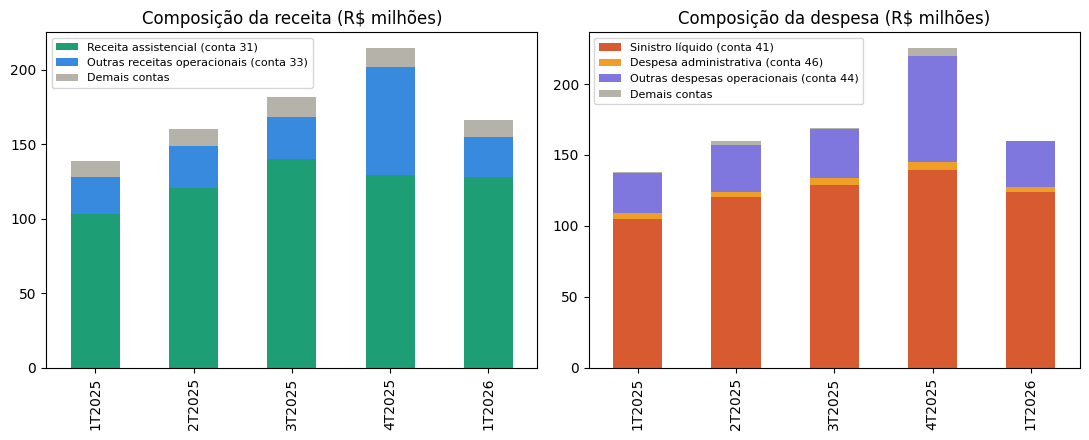

In [9]:
import numpy as np

pasa['residuo_receita'] = pasa['receitas_totais'] - pasa['receita_assistencial'] - pasa['outras_receitas_operacionais']
pasa['residuo_despesa'] = pasa['despesas_totais'] - pasa['sinistro_liquido'] - pasa['despesa_administrativa'] - pasa['outras_despesas_operacionais']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)

# Receitas
comp_receita = pasa[['receita_assistencial', 'outras_receitas_operacionais', 'residuo_receita']] / 1e6
comp_receita.plot(kind='bar', stacked=True, ax=axes[0],
                   color=['#1D9E75', '#378ADD', '#B4B2A9'])
axes[0].set_title('Composição da receita (R$ milhões)')
axes[0].set_xlabel('')
axes[0].legend(['Receita assistencial (conta 31)', 'Outras receitas operacionais (conta 33)', 'Demais contas'],
               fontsize=8, loc='upper left')

# Despesas
comp_despesa = pasa[['sinistro_liquido', 'despesa_administrativa', 'outras_despesas_operacionais', 'residuo_despesa']] / 1e6
comp_despesa.plot(kind='bar', stacked=True, ax=axes[1],
                   color=['#D85A30', '#EF9F27', '#7F77DD', '#B4B2A9'])
axes[1].set_title('Composição da despesa (R$ milhões)')
axes[1].set_xlabel('')
axes[1].legend(['Sinistro líquido (conta 41)', 'Despesa administrativa (conta 46)',
                'Outras despesas operacionais (conta 44)', 'Demais contas'],
               fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()


In [10]:
pasa['taxa_glosa'] = pasa['glosa'] / pasa['faturado_bruto']
pasa[['faturado_bruto', 'glosa', 'taxa_glosa']]


,faturado_bruto,glosa,taxa_glosa
trimestre,,,
1T2025,1.396485e+08,17810924.23,0.127541
2T2025,1.440838e+08,8952229.01,0.062132
3T2025,1.541985e+08,9155739.70,0.059376
4T2025,1.583006e+08,6696077.87,0.042300
1T2026,1.452767e+08,6068842.47,0.041774


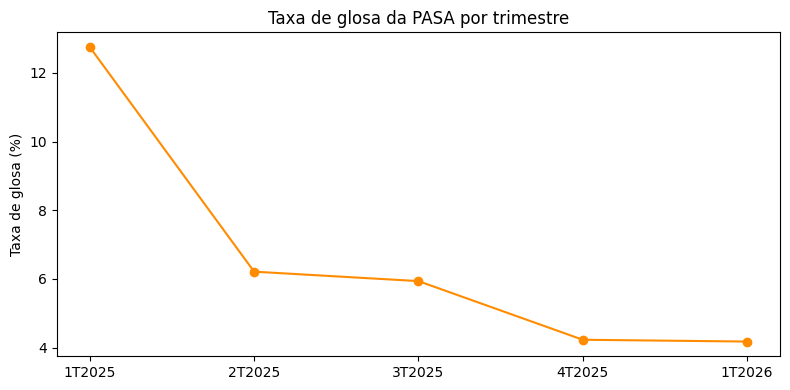

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pasa.index, pasa['taxa_glosa'] * 100, marker='o', color='darkorange')
ax.set_ylabel('Taxa de glosa (%)')
ax.set_title('Taxa de glosa da PASA por trimestre')
plt.tight_layout()
plt.show()


**Observação:** a taxa de glosa apresentou queda consistente ao longo do
período — de 12,75% no 1T2025 para 4,18% no 1T2026.

**Interpretação — questão em aberto:** essa redução pode ser compatível com
mais de uma explicação: uma melhora na qualidade do faturamento recebido dos
prestadores ou no processo de auditoria de contas, **ou** uma alteração no
padrão de controle/aceitação de faturas por parte da operadora. Os dados
públicos disponíveis não permitem, isoladamente, determinar qual explicação
(ou combinação de ambas) melhor descreve a variação observada. Esse ponto é
registrado aqui como uma pergunta em aberto, não como uma conclusão.

## 6. Síntese e perguntas em aberto

**O que foi observado:**
1. A sinistralidade da PASA esteve entre 92,3% e 107,4% ao longo de cinco
   trimestres, com três períodos acima de 100%.
2. A comparação contra um grupo de operadoras com perfil populacional mais
   semelhante (fundações de previdência) não sustentou a hipótese de que a
   composição etária da carteira, isoladamente, explica esse nível.
3. O detalhamento público da despesa assistencial não permitiu identificar
   uma categoria específica de custo associada ao nível de sinistralidade.
4. O resultado operacional completo — que inclui uma receita específica do
   regime de autogestão (Lei 13.127) fora da conta usada na sinistralidade —
   foi positivo em quatro dos cinco trimestres, indicando que a
   sinistralidade isolada não descreve completamente a situação financeira
   observada.
5. A taxa de glosa caiu de forma consistente no período, sem que os dados
   disponíveis permitam determinar a causa dessa variação.

**O que permanece em aberto:**
- Se o padrão de sinistralidade observado nestes cinco trimestres é
  representativo de um comportamento estrutural de prazo mais longo.
- Quais categorias específicas de utilização (procedimento, tipo de
  atendimento) mais contribuem para a despesa assistencial.
- Se a queda na taxa de glosa reflete eficiência de processo, mudança de
  critério de auditoria, ou ambos.

Essas questões, e as limitações metodológicas mais amplas do projeto, estão
consolidadas na seção *Limitações* do README.
